# Compressing Lyα-forest spectra: autoencoder versus PCA

This short notebook compares two forms of lossy data compression:

- **principal component analysis (PCA):** the best linear reconstruction for a
  fixed number of orthogonal components;
- **a nonlinear autoencoder:** a neural network trained to reproduce its input
  through a small latent bottleneck.

$$
F(x)\longrightarrow \underbrace{z}_{\text{compressed code}}
\longrightarrow \widehat F(x).
$$

The central question is empirical: **how many stored numbers per spectrum are
required to reach a chosen reconstruction fidelity?** For Lyα spectra lying on a
nonlinear physical manifold, an autoencoder can require a smaller latent vector
than the number of PCA coefficients needed for comparable test error.

We will measure that claim on held-out simulation realizations rather than assume
it in advance.

## Learning objectives

By the end, students should be able to:

1. distinguish compression from supervised physical-field inversion;
2. identify the autoencoder bottleneck as the compressed representation;
3. implement PCA compression using an SVD;
4. train a small convolutional autoencoder;
5. compare reconstruction error at equal code size;
6. find the PCA code size required to match a chosen autoencoder fidelity; and
7. distinguish per-spectrum code size from global decoder/model storage.

## 1. Imports and configuration

We compress noise-free, instrumentally smoothed flux. Random pixel noise is not
included in the target because incompressible noise would obscure the physical
compression question. Adding noise is proposed as an exercise.

In [ ]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from scipy import ndimage, special

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(7)
torch.manual_seed(7)
torch.use_deterministic_algorithms(True)
torch.set_num_threads(min(4, max(1, torch.get_num_threads())))
device = torch.device("cpu")

plt.rcParams.update({
    "figure.figsize": (10, 4.8), "figure.dpi": 120, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False,
})

BLACK, BLUE, ORANGE, PURPLE, GREY = (
    "#202020", "#2474A6", "#D97917", "#6A51A3", "#777777"
)

data_directory = Path("Sims/CMD_z=2_grid128")
box_size, redshift = 25.0, 2.0
h_camels, Omega_m = 0.6711, 0.30
instrument_fwhm_kms = 10.0

train_skewers_per_box = 64
validation_skewers_per_box = 32
test_skewers_per_box = 16
latent_dimensions = [2, 4, 8, 16, 32]
pca_dimensions = [1, 2, 4, 8, 12, 16, 24, 32, 48, 64]
reference_latent_dimension = 8
epochs = 35
batch_size = 64
learning_rate = 1.0e-3

print(f"PyTorch {torch.__version__}; device={device}")

PyTorch 2.13.0+cpu; device=cpu


## 2. Load fields and generate realistic spectra

H I density and temperature generate each spectrum through a continuous Voigt
calculation. Simulations 0–17 are used for training, 18–19 for validation, and
20–26 for the final test. PCA and the autoencoder receive identical splits.

Hubble flow and thermal broadening are included. Signed peculiar velocities are
omitted because no gas-velocity grid is supplied.

In [2]:
hi_path = data_directory / "Grids_HI_IllustrisTNG_CV_128_z=2.0.npy"
temperature_path = data_directory / "Grids_T_IllustrisTNG_CV_128_z=2.0.npy"
missing = [path for path in (hi_path, temperature_path) if not path.exists()]
if missing:
    raise FileNotFoundError("Missing CAMELS files:\n" +
                            "\n".join(f"  - {path}" for path in missing))

hi_boxes = np.load(hi_path, mmap_mode="r")
temperature_boxes = np.load(temperature_path, mmap_mode="r")
number_of_pixels = hi_boxes.shape[1]
cell_size = box_size / number_of_pixels
x = (np.arange(number_of_pixels)+0.5)*cell_size

training_simulations = np.arange(0, 18)
validation_simulations = np.arange(18, 20)
test_simulations = np.arange(20, 27)

MSUN_G, MPC_CM = 1.98847e33, 3.085677581e24
M_H_G, K_B = 1.6735575e-24, 1.380649e-16
C_CMS, C_KMS = 2.99792458e10, 2.99792458e5
LAMBDA_ALPHA_CM, GAMMA_ALPHA, I_ALPHA = 1215.67e-8, 6.262e8, 4.45e-18

H_z = 100*h_camels*np.sqrt(Omega_m*(1+redshift)**3 + 1-Omega_m)
distance_Mpc = (x-box_size/2)/h_camels
z_abs = redshift + H_z*distance_Mpc/C_KMS


def optical_depth(rho_hi_grid, temperature):
    rho_comoving = rho_hi_grid*MSUN_G*h_camels**2/MPC_CM**3
    n_hi = rho_comoving*(1+z_abs)**3/M_H_G
    b = np.sqrt(2*K_B*np.clip(temperature, 10, None)/M_H_G)
    nu_alpha = C_CMS/LAMBDA_ALPHA_CM
    damping = GAMMA_ALPHA*C_CMS/(4*np.pi*nu_alpha*b)
    velocity = C_CMS*(z_abs[:, None]-z_abs[None, :])/(1+z_abs[None, :])
    profile = np.real(special.wofz(velocity/b[:, None] + 1j*damping[:, None]))
    cell_width_cm = cell_size*MPC_CM/h_camels
    amplitude = C_CMS*I_ALPHA*cell_width_cm*n_hi/(
        np.sqrt(np.pi)*b*(1+z_abs)
    )
    return np.sum(amplitude[:, None]*profile, axis=0)


velocity_pixel_width = H_z*(cell_size/h_camels)/(1+redshift)
instrument_sigma_pixels = instrument_fwhm_kms/(
    2*np.sqrt(2*np.log(2))*velocity_pixel_width
)


def make_flux(rho_hi, temperature):
    intrinsic = np.exp(-optical_depth(rho_hi, temperature))
    return ndimage.gaussian_filter1d(
        intrinsic, instrument_sigma_pixels, mode="wrap"
    )

In [3]:
def choose_positions(number, rng, include_centre=False):
    centre = number_of_pixels//2
    selected = [(centre, centre)] if include_centre else []
    centre_flat = centre*number_of_pixels+centre
    available = np.delete(np.arange(number_of_pixels**2), centre_flat)
    draws = rng.choice(available, number-len(selected), replace=False)
    selected.extend(divmod(int(value), number_of_pixels) for value in draws)
    return selected


def build_flux_dataset(simulations, skewers_per_box, seed, include_centre=False):
    rng = np.random.default_rng(seed)
    spectra, labels = [], []
    for simulation in simulations:
        for y_index, z_index in choose_positions(
            skewers_per_box, rng, include_centre
        ):
            rho_hi = hi_boxes[simulation, :, y_index, z_index].astype(float)
            temperature = temperature_boxes[
                simulation, :, y_index, z_index
            ].astype(float)
            spectra.append(make_flux(rho_hi, temperature))
            labels.append(simulation)
    return np.asarray(spectra, np.float32), np.asarray(labels)


start = time.perf_counter()
train_flux, train_labels = build_flux_dataset(
    training_simulations, train_skewers_per_box, seed=101
)
validation_flux, validation_labels = build_flux_dataset(
    validation_simulations, validation_skewers_per_box, seed=202
)
test_flux, test_labels = build_flux_dataset(
    test_simulations, test_skewers_per_box, seed=303, include_centre=True
)
print("train / validation / test:", train_flux.shape,
      validation_flux.shape, test_flux.shape)
print(f"generation time={time.perf_counter()-start:.1f} s")

train / validation / test: (1152, 128) (64, 128) (112, 128)
generation time=5.2 s


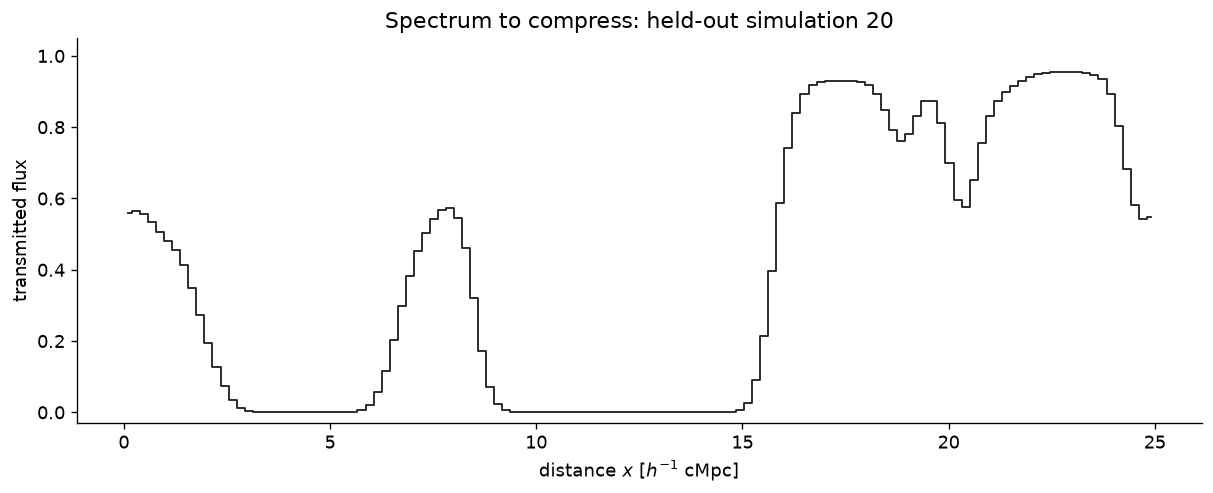

In [4]:
representative = 0
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
ax.step(x, test_flux[representative], where="mid", color=BLACK, lw=1.1)
ax.set(xlabel=r"distance $x$ [$h^{-1}$ cMpc]",
       ylabel="transmitted flux",
       title=f"Spectrum to compress: held-out simulation {test_labels[0]}")
ax.set_ylim(-0.03, 1.05)
plt.show()

## 3. PCA: the linear baseline

PCA finds orthogonal directions of decreasing variance. For $m$ components,

$$
z_{\rm PCA}=(F-\bar F)V_m^\mathsf{T},\qquad
\widehat F=\bar F+z_{\rm PCA}V_m.
$$

The compressed representation contains $m$ coefficients per spectrum. The basis
$V_m$ and mean spectrum are shared global decoder information.

In [5]:
# Standardize once so PCA and the autoencoder operate on the same numerical scale.
flux_mean = float(train_flux.mean())
flux_std = float(train_flux.std())

train_standard = (train_flux-flux_mean)/flux_std
validation_standard = (validation_flux-flux_mean)/flux_std
test_standard = (test_flux-flux_mean)/flux_std

pca_mean_spectrum = train_standard.mean(axis=0)
_, singular_values, pca_components = np.linalg.svd(
    train_standard-pca_mean_spectrum, full_matrices=False
)


def pca_encode(spectra, number_of_components):
    basis = pca_components[:number_of_components]
    return (spectra-pca_mean_spectrum)@basis.T


def pca_decode(coefficients, number_of_components):
    basis = pca_components[:number_of_components]
    return pca_mean_spectrum + coefficients@basis


def pca_reconstruct(spectra, number_of_components):
    coefficients = pca_encode(spectra, number_of_components)
    return pca_decode(coefficients, number_of_components)


variance_fraction = singular_values**2/np.sum(singular_values**2)
print("Variance explained by first 8 PCs:", variance_fraction[:8].sum())

Variance explained by first 8 PCs: 0.69811577


## 4. Nonlinear convolutional autoencoder

The encoder reduces a 128-pixel spectrum to a vector $z\in\mathbb R^d$. This
vector—not the hidden feature maps—is the stored compressed data. The decoder maps
$z$ back to a reconstructed spectrum.

Nonlinear activations allow the learned manifold to curve through the original
128-dimensional flux space, whereas PCA is restricted to one linear subspace.

In [6]:
class SpectralAutoencoder(nn.Module):
    def __init__(self, latent_dimension):
        super().__init__()
        self.latent_dimension = latent_dimension

        self.encoder_convolution = nn.Sequential(
            nn.Conv1d(1, 8, 5, padding=2, padding_mode="circular"), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(8, 16, 5, padding=2, padding_mode="circular"), nn.ReLU(),
            nn.MaxPool1d(2),
        )
        self.to_latent = nn.Linear(16*32, latent_dimension)

        self.from_latent = nn.Linear(latent_dimension, 16*32)
        self.decoder_half = nn.Sequential(
            nn.Conv1d(16, 8, 5, padding=2, padding_mode="circular"), nn.ReLU(),
        )
        self.decoder_full = nn.Sequential(
            nn.Conv1d(8, 4, 5, padding=2, padding_mode="circular"), nn.ReLU(),
            nn.Conv1d(4, 1, 3, padding=1, padding_mode="circular"),
        )

    def encode(self, spectra):
        features = self.encoder_convolution(spectra)
        return self.to_latent(features.flatten(start_dim=1))

    def decode(self, latent):
        features = self.from_latent(latent).reshape(-1, 16, 32)
        features = F.interpolate(
            features, size=64, mode="linear", align_corners=False
        )
        features = self.decoder_half(features)
        features = F.interpolate(
            features, size=128, mode="linear", align_corners=False
        )
        return self.decoder_full(features)

    def forward(self, spectra):
        return self.decode(self.encode(spectra))

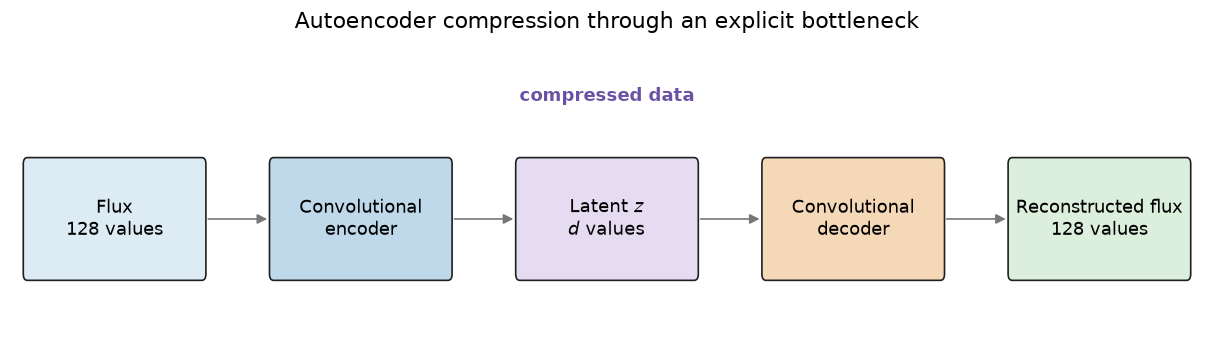

In [7]:
def architecture_box(ax, x_position, text, colour, width=1.7):
    patch = FancyBboxPatch(
        (x_position-width/2, 0.65), width, 0.7,
        boxstyle="round,pad=0.04", facecolor=colour,
        edgecolor=BLACK, linewidth=1.0
    )
    ax.add_patch(patch)
    ax.text(x_position, 1.0, text, ha="center", va="center")


fig, ax = plt.subplots(figsize=(10, 2.8), constrained_layout=True)
nodes = [
    (1.0, "Flux\n128 values", "#DDEBF4"),
    (3.4, "Convolutional\nencoder", "#BFD9EA"),
    (5.8, "Latent $z$\n$d$ values", "#E5DCF2"),
    (8.2, "Convolutional\ndecoder", "#F4D8B8"),
    (10.6, "Reconstructed flux\n128 values", "#DCEEDC"),
]
for x_position, label, colour in nodes:
    architecture_box(ax, x_position, label, colour)
for left, right in zip(nodes[:-1], nodes[1:]):
    ax.add_patch(FancyArrowPatch(
        (left[0]+0.88, 1.0), (right[0]-0.88, 1.0),
        arrowstyle="-|>", mutation_scale=12, color=GREY
    ))
ax.text(5.8, 1.75, "compressed data", color=PURPLE,
        ha="center", fontweight="bold")
ax.set_xlim(0, 11.6)
ax.set_ylim(0.25, 2.15)
ax.axis("off")
ax.set_title("Autoencoder compression through an explicit bottleneck")
plt.show()

## 5. Train several bottleneck sizes

Each model reconstructs its input and is selected using validation MSE. The test
simulations are not used for training or epoch selection.

In [8]:
def spectrum_tensor(array):
    return torch.tensor(array[:, None, :], dtype=torch.float32)


training_set = TensorDataset(spectrum_tensor(train_standard))
validation_set = TensorDataset(spectrum_tensor(validation_standard))
validation_loader = DataLoader(
    validation_set, batch_size=128, shuffle=False, num_workers=0
)


def train_autoencoder(latent_dimension):
    torch.manual_seed(100+latent_dimension)
    model = SpectralAutoencoder(latent_dimension).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_function = nn.MSELoss()
    history = {"train": [], "validation": []}
    best_loss, best_state = np.inf, None

    generator = torch.Generator().manual_seed(200+latent_dimension)
    training_loader = DataLoader(
        training_set, batch_size=batch_size, shuffle=True,
        generator=generator, num_workers=0
    )

    for epoch in range(epochs):
        model.train()
        training_sum = 0.0
        for (batch,) in training_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            loss = loss_function(model(batch), batch)
            loss.backward()
            optimizer.step()
            training_sum += loss.item()*batch.size(0)

        model.eval()
        validation_sum = 0.0
        with torch.no_grad():
            for (batch,) in validation_loader:
                batch = batch.to(device)
                validation_sum += (
                    loss_function(model(batch), batch).item()*batch.size(0)
                )
        train_loss = training_sum/len(training_set)
        validation_loss = validation_sum/len(validation_set)
        history["train"].append(train_loss)
        history["validation"].append(validation_loss)
        if validation_loss < best_loss:
            best_loss = validation_loss
            best_state = {
                name: value.detach().cpu().clone()
                for name, value in model.state_dict().items()
            }

    model.load_state_dict(best_state)
    print(f"latent={latent_dimension:2d}: best validation MSE={best_loss:.5f}")
    return model, history


autoencoders, histories = {}, {}
training_start = time.perf_counter()
for latent_dimension in latent_dimensions:
    autoencoders[latent_dimension], histories[latent_dimension] = (
        train_autoencoder(latent_dimension)
    )
print(f"total training time={time.perf_counter()-training_start:.1f} s")

latent= 2: best validation MSE=0.75355
latent= 4: best validation MSE=0.56621
latent= 8: best validation MSE=0.33429
latent=16: best validation MSE=0.10192
latent=32: best validation MSE=0.28639
total training time=74.3 s


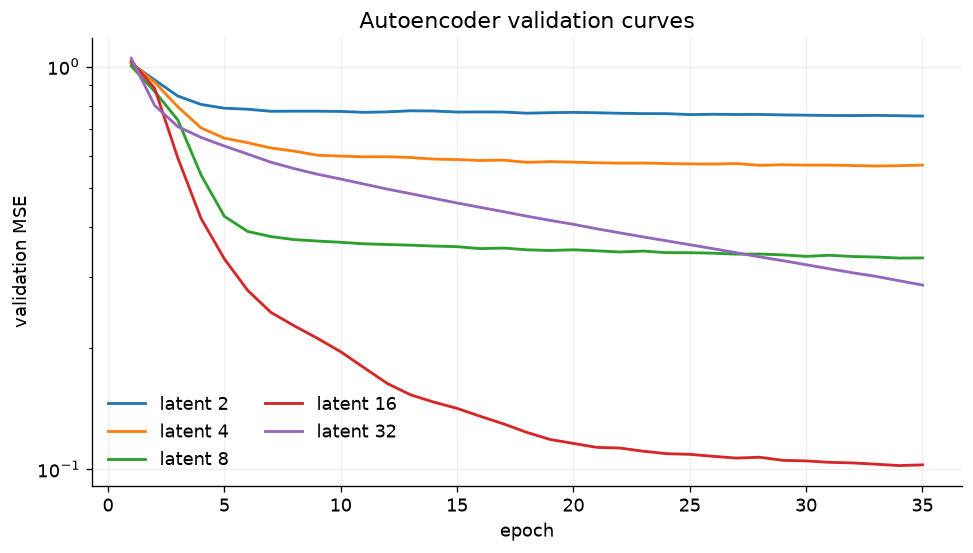

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
for latent_dimension in latent_dimensions:
    ax.semilogy(np.arange(1, epochs+1),
                histories[latent_dimension]["validation"],
                lw=1.7, label=f"latent {latent_dimension}")
ax.set(xlabel="epoch", ylabel="validation MSE",
       title="Autoencoder validation curves")
ax.grid(alpha=0.2)
ax.legend(ncol=2)
plt.show()

## 6. Extract the compressed latent arrays

Calling `encode` stops at the bottleneck. For a test set containing $N$ spectra,
the stored array has shape $(N,d)$ and contains $Nd$ floating-point numbers.

In [10]:
test_tensor = spectrum_tensor(test_standard).to(device)
autoencoder_latents = {}
autoencoder_reconstructions = {}

for latent_dimension, model in autoencoders.items():
    model.eval()
    with torch.no_grad():
        latent = model.encode(test_tensor)
        reconstruction = model.decode(latent)
    autoencoder_latents[latent_dimension] = latent.cpu().numpy()
    autoencoder_reconstructions[latent_dimension] = (
        reconstruction.cpu().numpy()[:, 0]
    )

example_latent = autoencoder_latents[reference_latent_dimension]
print("Original test array:", test_standard.shape)
print("Compressed latent array:", example_latent.shape)
print(f"Per-spectrum compression ratio: "
      f"{number_of_pixels/reference_latent_dimension:.1f}:1")

Original test array: (112, 128)
Compressed latent array: (112, 8)
Per-spectrum compression ratio: 16.0:1


## 7. Fidelity as a function of compressed code size

We use normalized RMSE,

$$
{\rm NRMSE}=\frac{
\sqrt{\langle(\widehat F-F)^2\rangle}}
{\sigma_{F,\rm train}}.
$$

The metric is calculated per sightline, averaged within each test simulation, and
then summarized by the mean and standard deviation across simulations 20–26.

In [11]:
def nrmse_per_spectrum(truth, reconstruction):
    return np.sqrt(np.mean((reconstruction-truth)**2, axis=1))


def average_by_test_simulation(values):
    return np.array([
        values[test_labels == simulation].mean()
        for simulation in test_simulations
    ])


pca_reconstructions = {
    dimension: pca_reconstruct(test_standard, dimension)
    for dimension in pca_dimensions
}

autoencoder_errors = {
    dimension: average_by_test_simulation(nrmse_per_spectrum(
        test_standard, reconstruction
    ))
    for dimension, reconstruction in autoencoder_reconstructions.items()
}
pca_errors = {
    dimension: average_by_test_simulation(nrmse_per_spectrum(
        test_standard, reconstruction
    ))
    for dimension, reconstruction in pca_reconstructions.items()
}

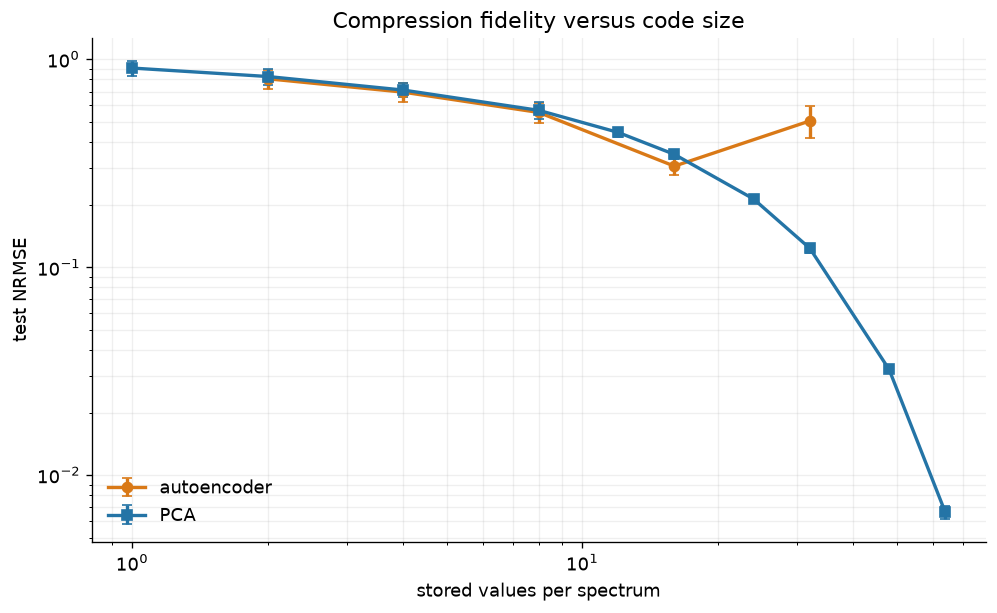

In [12]:
fig, ax = plt.subplots(figsize=(8.2, 5), constrained_layout=True)
for dimensions, errors, label, colour, marker in [
    (latent_dimensions, autoencoder_errors, "autoencoder", ORANGE, "o"),
    (pca_dimensions, pca_errors, "PCA", BLUE, "s"),
]:
    means = [errors[dimension].mean() for dimension in dimensions]
    standard_deviations = [errors[dimension].std(ddof=1)
                           for dimension in dimensions]
    ax.errorbar(dimensions, means, yerr=standard_deviations,
                color=colour, marker=marker, lw=2, capsize=3, label=label)
ax.set(xscale="log", yscale="log",
       xlabel="stored values per spectrum",
       ylabel="test NRMSE",
       title="Compression fidelity versus code size")
ax.grid(alpha=0.2, which="both")
ax.legend()
plt.show()

## 8. Matched-fidelity comparison

We take the test fidelity of the eight-dimensional autoencoder as a transparent
reference and find the smallest tested PCA representation whose mean error is no
larger. This answers the requested question without comparing arbitrarily selected
models.

If PCA reaches the target with fewer coefficients, the data do not support an
autoencoder compression advantage under this setup. The code reports that outcome
honestly rather than forcing a conclusion.

In [13]:
reference_error = autoencoder_errors[reference_latent_dimension].mean()
qualifying_pca_dimensions = [
    dimension for dimension in pca_dimensions
    if pca_errors[dimension].mean() <= reference_error
]
matched_pca_dimension = (
    min(qualifying_pca_dimensions)
    if qualifying_pca_dimensions else max(pca_dimensions)
)
pca_reached_target = bool(qualifying_pca_dimensions)

print(f"Reference autoencoder: {reference_latent_dimension} latent values")
print(f"Reference mean test NRMSE: {reference_error:.4f}")
if pca_reached_target:
    print(f"Smallest tested PCA code reaching this fidelity: "
          f"{matched_pca_dimension} coefficients")
else:
    print(f"PCA did not reach this fidelity with up to "
          f"{matched_pca_dimension} coefficients")

if matched_pca_dimension > reference_latent_dimension:
    print("Result: the autoencoder uses the smaller per-spectrum code.")
elif matched_pca_dimension == reference_latent_dimension:
    print("Result: both methods require the same tested code size.")
else:
    print("Result: PCA uses the smaller code for this experiment.")

Reference autoencoder: 8 latent values
Reference mean test NRMSE: 0.5552
Smallest tested PCA code reaching this fidelity: 12 coefficients
Result: the autoencoder uses the smaller per-spectrum code.


Per-dataset compressed arrays, stored as float32
Original:      14336 values, 56.0 KiB
Autoencoder:     896 values, 3.5 KiB
PCA:            1344 values, 5.2 KiB


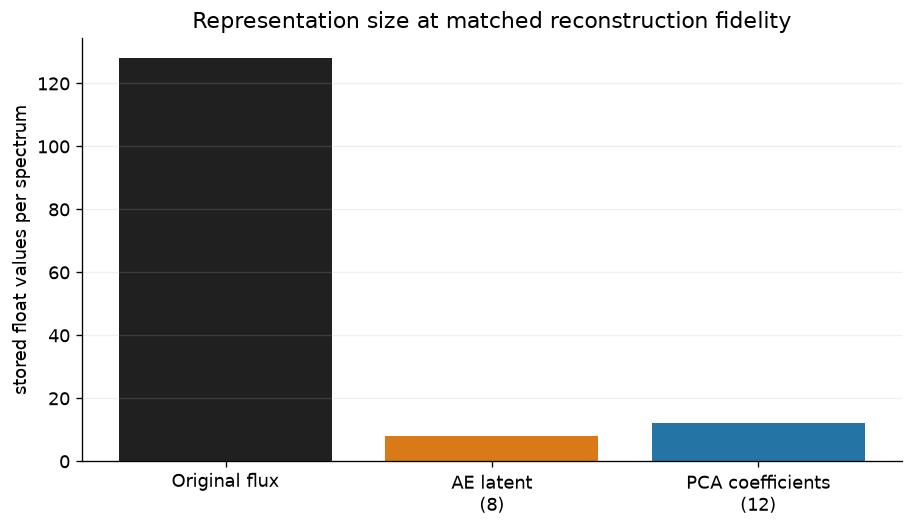

In [14]:
original_values = test_standard.size
ae_values = autoencoder_latents[reference_latent_dimension].size
pca_coefficients = pca_encode(test_standard, matched_pca_dimension)
pca_values = pca_coefficients.size

print("Per-dataset compressed arrays, stored as float32")
print(f"Original:    {original_values:7d} values, "
      f"{4*original_values/1024:.1f} KiB")
print(f"Autoencoder: {ae_values:7d} values, {4*ae_values/1024:.1f} KiB")
print(f"PCA:         {pca_values:7d} values, {4*pca_values/1024:.1f} KiB")

fig, ax = plt.subplots(figsize=(7.5, 4.3), constrained_layout=True)
labels = ["Original flux", f"AE latent\n({reference_latent_dimension})",
          f"PCA coefficients\n({matched_pca_dimension})"]
values_per_spectrum = [number_of_pixels, reference_latent_dimension,
                       matched_pca_dimension]
ax.bar(labels, values_per_spectrum, color=[BLACK, ORANGE, BLUE])
ax.set_ylabel("stored float values per spectrum")
ax.set_title("Representation size at matched reconstruction fidelity")
ax.grid(axis="y", alpha=0.2)
plt.show()

## 9. Visual reconstruction at matched fidelity

The residual panel is important: two reconstructions may appear nearly identical
by eye while differing systematically in deep or narrow absorption features.

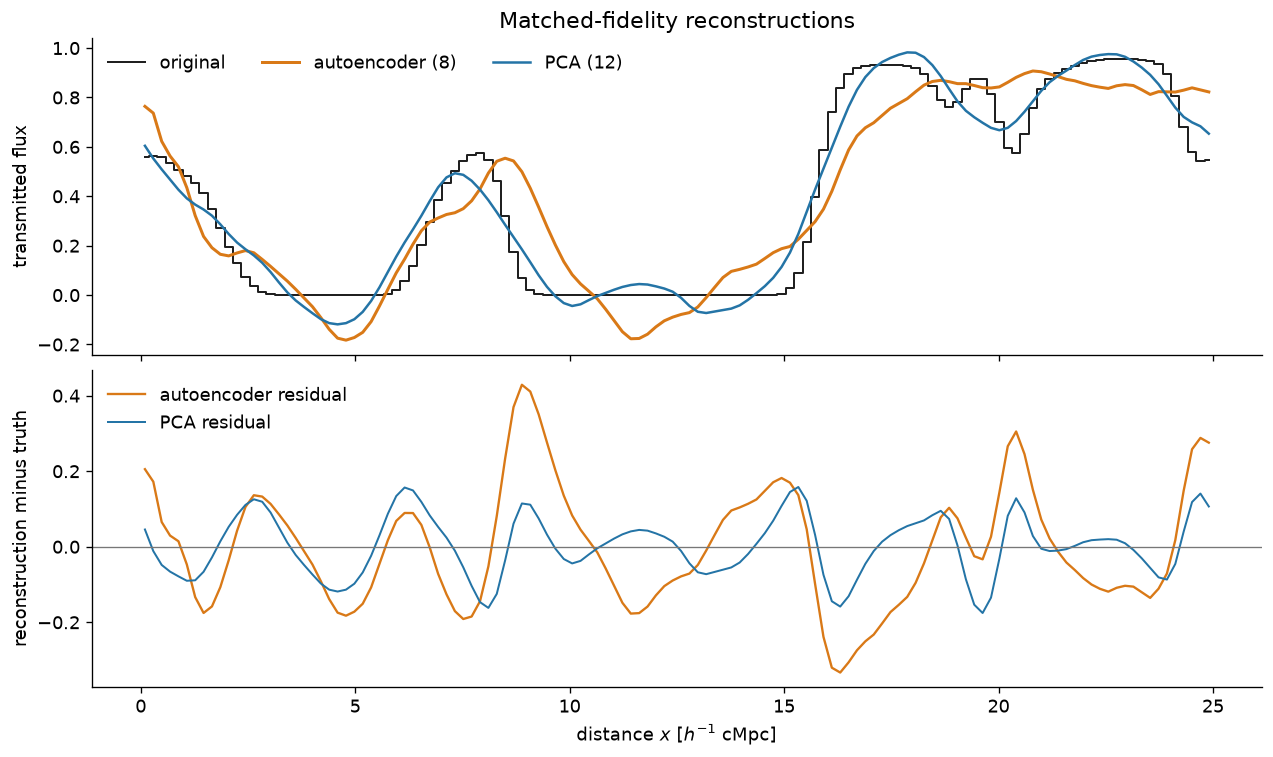

In [15]:
ae_standard = autoencoder_reconstructions[reference_latent_dimension][representative]
pca_standard = pca_reconstructions[matched_pca_dimension][representative]

original_flux = test_flux[representative]
ae_flux = flux_mean + flux_std*ae_standard
pca_flux = flux_mean + flux_std*pca_standard

fig, axes = plt.subplots(2, 1, figsize=(10.5, 6.2),
                         sharex=True, constrained_layout=True)
axes[0].step(x, original_flux, where="mid", color=BLACK, lw=1.2,
             label="original")
axes[0].plot(x, ae_flux, color=ORANGE, lw=1.8,
             label=f"autoencoder ({reference_latent_dimension})")
axes[0].plot(x, pca_flux, color=BLUE, lw=1.5,
             label=f"PCA ({matched_pca_dimension})")
axes[0].set_ylabel("transmitted flux")
axes[0].set_title("Matched-fidelity reconstructions")
axes[0].legend(ncol=3)

axes[1].plot(x, ae_flux-original_flux, color=ORANGE, lw=1.4,
             label="autoencoder residual")
axes[1].plot(x, pca_flux-original_flux, color=BLUE, lw=1.2,
             label="PCA residual")
axes[1].axhline(0, color=GREY, lw=0.8)
axes[1].set(xlabel=r"distance $x$ [$h^{-1}$ cMpc]",
            ylabel="reconstruction minus truth")
axes[1].legend()
plt.show()

## 10. Code size is not the whole storage cost

The comparison above concerns the **per-spectrum compressed array**. A usable
compressor must also store its shared decoder:

- PCA stores its mean spectrum and component basis;
- the autoencoder stores all trained network parameters.

The neural decoder is usually much larger. Its smaller per-spectrum code becomes
advantageous only when sufficiently many spectra share the same trained model.

In [16]:
ae_parameters = sum(parameter.numel() for parameter in
                    autoencoders[reference_latent_dimension].parameters())
pca_decoder_values = number_of_pixels*(matched_pca_dimension+1)

print("Shared decoder/model storage, assuming float32")
print(f"Autoencoder weights: {ae_parameters:,} values "
      f"({4*ae_parameters/1024:.1f} KiB)")
print(f"PCA mean + basis:    {pca_decoder_values:,} values "
      f"({4*pca_decoder_values/1024:.1f} KiB)")

if matched_pca_dimension > reference_latent_dimension:
    extra_model_values = ae_parameters-pca_decoder_values
    saved_per_spectrum = matched_pca_dimension-reference_latent_dimension
    if extra_model_values > 0 and saved_per_spectrum > 0:
        break_even = int(np.ceil(extra_model_values/saved_per_spectrum))
        print(f"Approximate float-count break-even dataset size: "
              f"{break_even:,} spectra")

Shared decoder/model storage, assuming float32
Autoencoder weights: 10,241 values (40.0 KiB)
PCA mean + basis:    1,664 values (6.5 KiB)
Approximate float-count break-even dataset size: 2,145 spectra


## Conclusions

- PCA is an optimal **linear** baseline and requires no iterative neural training.
- The autoencoder learns a nonlinear encoder and decoder through an explicit latent
  bottleneck.
- The fidelity-versus-code-size curve determines whether nonlinear compression is
  actually better for these held-out Lyα spectra.
- At matched fidelity, compare latent dimension with PCA component count—not the
  names of the methods.
- A smaller latent array does not imply smaller total storage for a small dataset;
  shared model/basis overhead must also be reported.
- Results depend on the simulation family, preprocessing, architecture, training,
  and fidelity metric. “Neural networks compress better” is an empirical conclusion,
  not a universal theorem.

## Exercises

1. Repeat the comparison at latent dimensions 1, 3, 6, 12, and 24.
2. Add Gaussian noise and compare reconstruction of the noisy input with
   reconstruction of the underlying clean flux. Explain the difference between an
   autoencoder and a denoising autoencoder.
3. Replace ReLU by a purely linear activation. Show that the nonlinear advantage
   largely disappears and relate the result to PCA.
4. Compare errors in high-transmission and strong-absorption pixels separately.
5. Train on one instrumental resolution and test on another to examine whether the
   learned compression transfers.
6. Plot the two-dimensional latent space for $d=2$, coloured by mean transmitted
   flux or effective optical depth. Identify what physical ordering the network
   learned.

## Final take-away

> PCA stores coordinates on a linear subspace. An autoencoder can learn a curved
> low-dimensional manifold and may therefore reach the same Lyα-flux reconstruction
> fidelity with fewer stored latent values per spectrum. The correct demonstration
> is the held-out fidelity-versus-code-size curve, together with an honest accounting
> of shared decoder storage.